# Forward Functions

In this notebook we have a look at the different forward functions of the SNN class.

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from eventpropjax.evnn import FFEvNN
from eventpropjax.neuron_models import LIF

In [71]:
key = jax.random.PRNGKey(0)

snn = FFEvNN(
    layers=[5, 5, 5],
    in_size=1,
    neuron_model=LIF,
    max_solver_time=30.0,
    key=key,
    buffer_capacity=2000,
    solver_stepsize=0.001,
    max_event_steps=2000,
    output_no_spike_value=jnp.inf,
    thresh=1.0,
    tsyn=5.0,
    tmem=20.0,
    init_bias=0.1,
    dlim=4.0,
    wlim=3.0
)

# choice of the models input we use for all fwd functions
in_spikes = jnp.array([[0.0, 0.5, 1.0, 1.5, 2.0]])

## Investigate the Neurons State at specific times

With the function `state_at_t` we can observe the output neurons states at given timepoints. The function returns an array with the shape `(output_neurons, timepoints, neuron_model_state_dimension)`. We can use this to display the state over time or to formulate a state-based loss function:

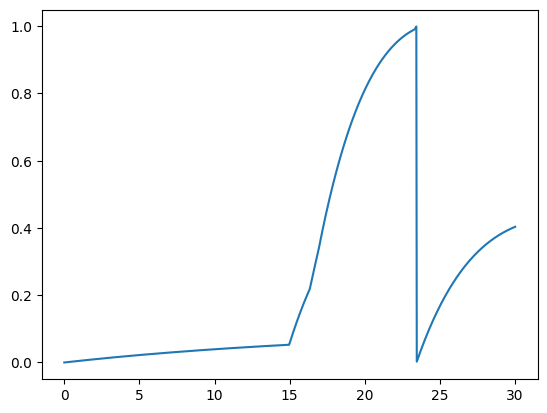

In [73]:
# specify the observation times
times = jnp.linspace(0, 30.0, 1000)

state_over_time = snn.state_at_t(in_spikes, times)

plt.plot(times, state_over_time[1, :, 0])
plt.show()